# Khởi tạo môi trường (Setup)

In [2]:
# Cài đặt thư viện YOLOv8 từ Ultralytics
!pip install ultralytics -q

import os
import shutil
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import display, Image

# Kiểm tra GPU có sẵn không (Kaggle P100 hoặc T4)
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.2 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA Available: True
GPU: Tesla T4


In [ ]:
# THAY ĐỔI: Tên dataset bạn đã đặt khi upload lên Kaggle
DATASET_NAME = "traffic-vietnam-v1" 

# Đường dẫn chuẩn trên Kaggle
YAML_PATH = f"/kaggle/input/datasets/thhtmnguyn21/traffic-project/traffic-vietnam-v1/data.yaml"
PROJECT_DIR = "/kaggle/working/Traffic_Project"
RUN_NAME = "run_small_1024"

print(f"Đường dẫn file cấu hình: {YAML_PATH}")
# Kiểm tra xem file yaml có tồn tại không để tránh lỗi
if os.path.exists(YAML_PATH):
    print("Dữ liệu đã sẵn sàng!")
else:
    print("Không tìm thấy file data.yaml. Hãy kiểm tra lại tên Dataset.")

# Huấn luyện mô hình (Training)


In [ ]:
# Khởi tạo mô hình Small (Transfer Learning)
model = YOLO("yolov8s.pt")

# Bắt đầu huấn luyện với cấu hình ÉP XUNG TỐI ĐA
results = model.train(
    data=YAML_PATH,
    project=PROJECT_DIR,
    name="model_yolov8_small_1024", 
    
    # 1. Quản lý vòng lặp (Nới lỏng sức bền)
    epochs=150,        
    patience=50,       # TĂNG LÊN 50: Tránh bị dừng quá sớm như hôm qua
    
    # 2. Cấu hình phần cứng
    imgsz=1024,        
    batch=8,           
    device=0,
    
    # 3. Tối ưu hóa thuật toán (Học mượt hơn)
    optimizer="AdamW", 
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,       # MỚI: Kích hoạt sóng Cosine để mAP50-95 tăng mạnh
    weight_decay=0.0005,
    
    # 4. Tăng cường dữ liệu (Trị tận gốc xe bị che khuất)
    mosaic=1.0,        
    mixup=0.1,         # MỚI: Trộn ảnh đè lên nhau để học cách nhìn xuyên thấu
    degrees=10.0,      # MỚI: Xoay ảnh nhẹ giả lập camera rung lắc
    close_mosaic=15    
)

# Trực quan hóa kết quả (Visualization)

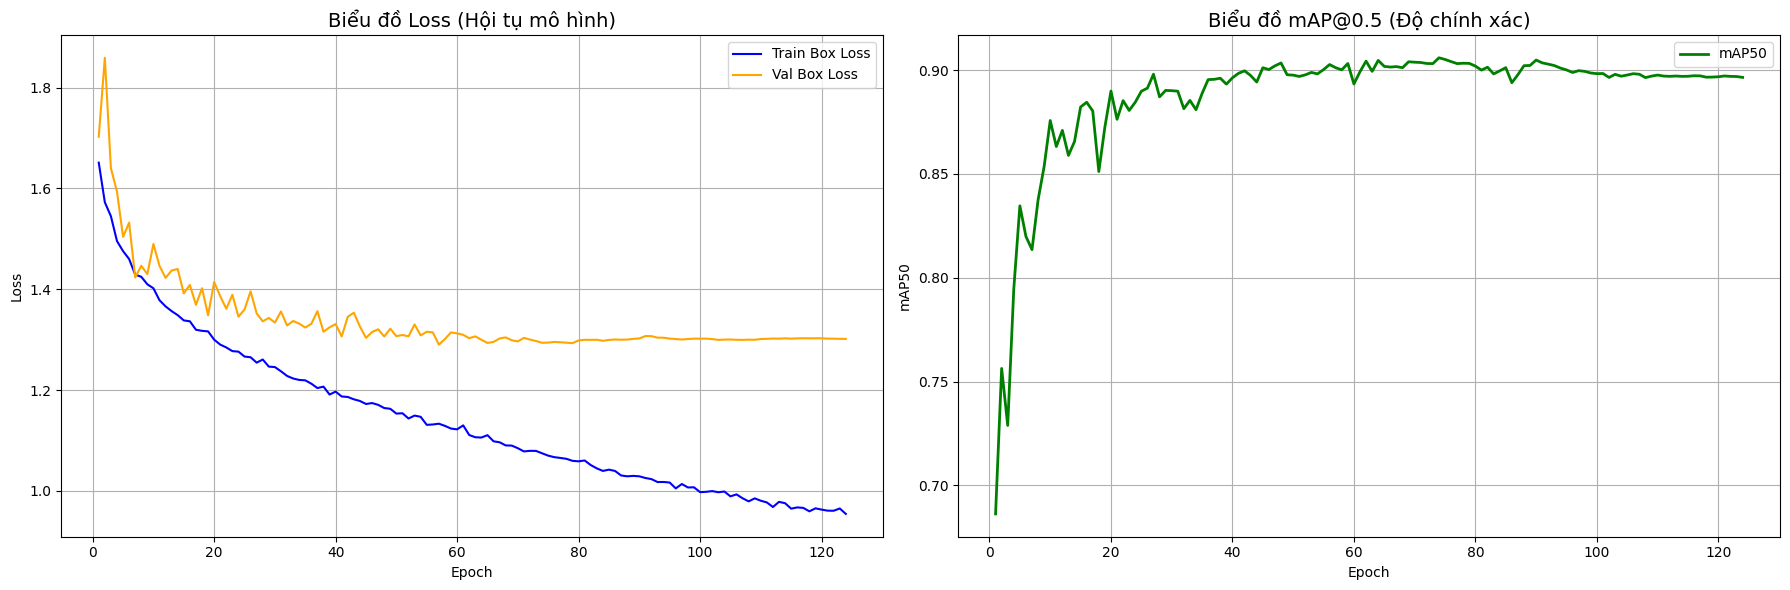

✅ Đã vẽ xong biểu đồ! Bạn có thể tải file custom_results.png về làm báo cáo.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. ĐƯỜNG DẪN TỚI FILE CSV
# ==========================================
CSV_PATH = "/kaggle/input/notebooks/thhtmnguyn21/trafic-project/Traffic_Project/model_yolov8_small_1024/results.csv"

if os.path.exists(CSV_PATH):
    # Đọc dữ liệu từ file CSV
    df = pd.read_csv(CSV_PATH)
    
    # Làm sạch tên cột (xóa các khoảng trắng thừa)
    df.columns = [c.strip() for c in df.columns]

    # 2. VẼ BIỂU ĐỒ
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    # Đồ thị 1: Train & Val Loss
    ax[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue')
    ax[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='orange')
    ax[0].set_title('Biểu đồ Loss (Hội tụ mô hình)', fontsize=14)
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)

    # Đồ thị 2: mAP50
    ax[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green', linewidth=2)
    ax[1].set_title('Biểu đồ mAP@0.5 (Độ chính xác)', fontsize=14)
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('mAP50')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.savefig("/kaggle/working/custom_results.png", dpi=300)
    plt.show()
    
    print("✅ Đã vẽ xong biểu đồ! Bạn có thể tải file custom_results.png về làm báo cáo.")
else:
    print("❌ Không tìm thấy file CSV. Hãy kiểm tra lại đường dẫn!")

# Đánh giá kết quả

In [ ]:
# Đường dẫn file trọng số tốt nhất sau khi train
best_weights = f"{result_dir}/weights/best.pt"

if os.path.exists(best_weights):
    print("ĐANG CHẠY KIỂM THỬ TRÊN TẬP TEST (DỮ LIỆU LẠ)...")
    final_model = YOLO(best_weights)
    
    # Ép dùng imgsz=1024 để đánh giá công bằng
    metrics = final_model.val(data=YAML_PATH, split='test', imgsz=1024)
    
    print("KẾT QUẢ CUỐI CÙNG CHO BÁO CÁO:")
    print(f"- mAP50: {metrics.box.map50:.4f}")
    print(f"- Precision (P): {metrics.box.mp:.4f}")
    print(f"- Recall (R): {metrics.box.mr:.4f}")
else:
    print("Không tìm thấy file trọng số. Có thể quá trình train chưa hoàn tất.")

In [3]:
from ultralytics import YOLO

# Thay đường dẫn tới file best.pt bạn vừa lấy được
model = YOLO("/kaggle/input/notebooks/thhtmnguyn21/trafic-project/Traffic_Project/model_yolov8_small_1024/weights/best.pt")

# Thay đường dẫn tới data.yaml của bạn
YAML_PATH = "/kaggle/input/datasets/thhtmnguyn21/traffic-project/traffic-vietnam-v1/data.yaml"

print("🔍 ĐANG ĐÁNH GIÁ CHẤT LƯỢNG MÔ HÌNH 12 TIẾNG...")
metrics = model.val(data=YAML_PATH, split='test', imgsz=1024)

print("\n🎯 KẾT QUẢ CUỐI CÙNG:")
print(f"- mAP50: {metrics.box.map50:.4f}")

🔍 ĐANG ĐÁNH GIÁ CHẤT LƯỢNG MÔ HÌNH 12 TIẾNG...
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 14.1±11.7 MB/s, size: 72.4 KB)
val: Scanning /kaggle/input/datasets/thhtmnguyn21/traffic-project/traffic-vietnam-v1/test/labels... 265 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 265/265 119.5it/s 2.2s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/thhtmnguyn21/traffic-project/traffic-vietnam-v1/test is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 343, len(boxes) = 4114. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1

In [7]:
!pip install sahi ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 31.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


🚀 ĐANG KHỞI TẠO MÔ HÌNH VỚI SAHI...
🔪 ĐANG BĂM ẢNH VÀ NHẬN DIỆN CHI TIẾT...
Performing prediction on 9 slices.
✅ HOÀN TẤT!


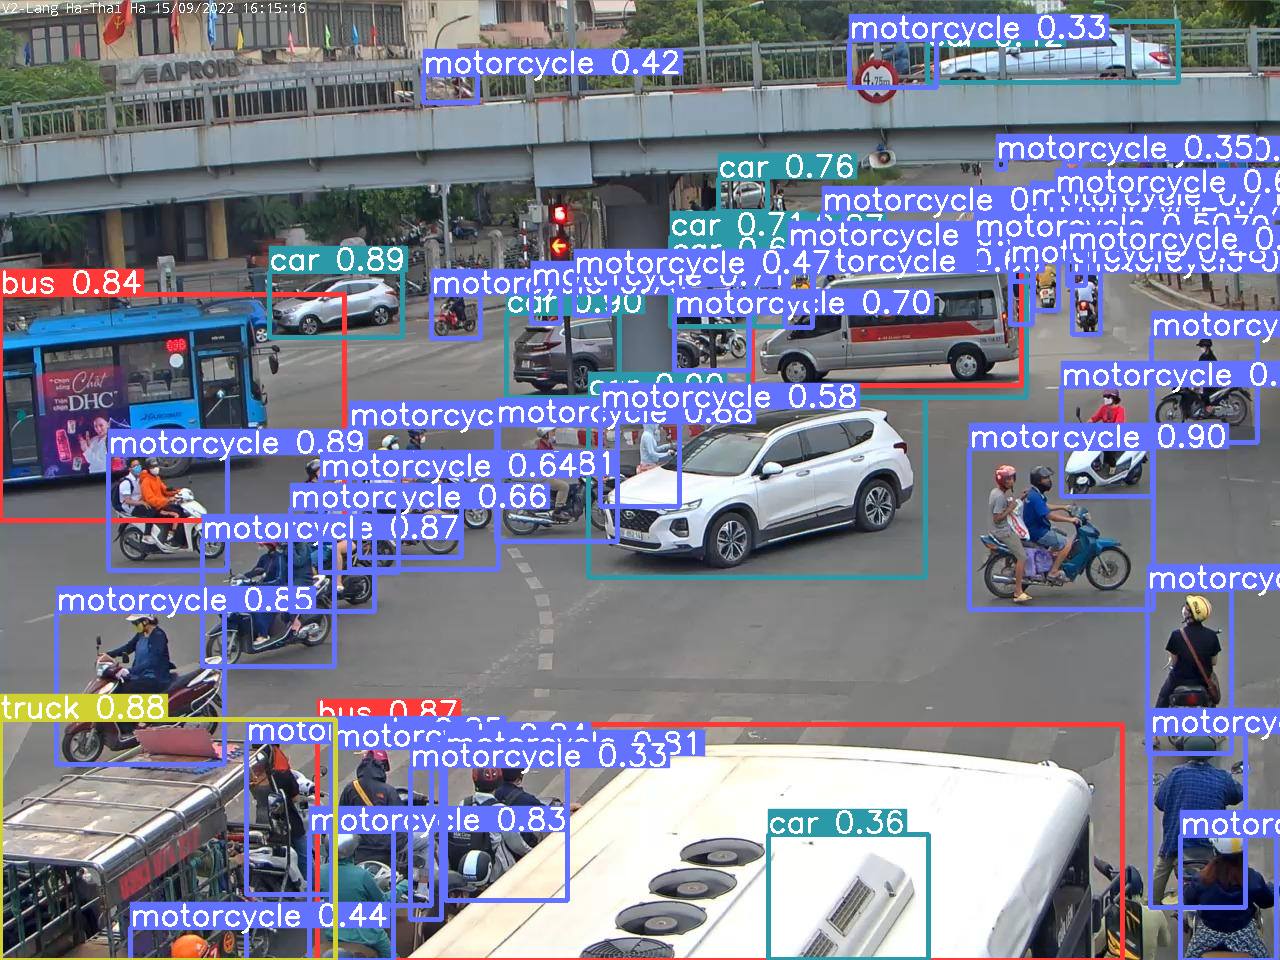

In [8]:
import os
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from IPython.display import display, Image

# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN 
# ==========================================
# Đường dẫn tới file best.pt bạn vừa tải về 
WEIGHTS_PATH = "/kaggle/input/notebooks/thhtmnguyn21/trafic-project/Traffic_Project/model_yolov8_small_1024/weights/best.pt"

# Chuẩn bị một bức ảnh giao thông 4K hoặc Full HD để test (bạn tự upload lên Kaggle)
# Ví dụ: Tải một ảnh từ thư mục test của tập data
TEST_IMAGE_PATH = "/kaggle/input/datasets/thhtmnguyn21/traffic-project/traffic-vietnam-v1/test/images/16h15_15_9_22_mp4-0000_jpg.rf.d61b29d61bb4589d627a8f8626d90154.jpg" 

print("🚀 ĐANG KHỞI TẠO MÔ HÌNH VỚI SAHI...")

# 1. Load mô hình YOLOv8 vào khung của SAHI
detection_model = AutoDetectionModel.from_pretrained(
    model_type='yolov8',
    model_path=WEIGHTS_PATH,
    confidence_threshold=0.3, # Bắt các vật thể có độ tự tin > 30%
    device="cuda:0" # Dùng GPU. Nếu chạy trên máy tính không có card rời thì đổi thành "cpu"
)

print("🔪 ĐANG BĂM ẢNH VÀ NHẬN DIỆN CHI TIẾT...")

# 2. Chạy thuật toán SAHI
# Cắt ảnh thành các khung 512x512, tỷ lệ đè lên nhau (overlap) là 20% để không làm đứt đôi cái xe
result = get_sliced_prediction(
    TEST_IMAGE_PATH,
    detection_model,
    slice_height=512,
    slice_width=512,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2
)

# 3. Xuất kết quả ra thư mục hiện tại
OUTPUT_DIR = "/kaggle/working/sahi_demo/"
result.export_visuals(export_dir=OUTPUT_DIR, file_name="ket_qua_sahi")

print("✅ HOÀN TẤT!")

# 4. Hiển thị ảnh kết quả lên màn hình
result_img_path = f"{OUTPUT_DIR}/ket_qua_sahi.png"
if os.path.exists(result_img_path):
    display(Image(filename=result_img_path, width=800))

⏳ ĐANG CHẠY THỬ NGHIỆM A/B TESTING...

▶️ 1. Đang chạy YOLOv8 tiêu chuẩn...
   -> YOLO thường phát hiện được: 30 đối tượng.
▶️ 2. Đang chạy YOLOv8 + SAHI...
   -> SAHI phát hiện được: 33 đối tượng.

🏆 KẾT LUẬN: SAHI TĂNG HIỆU SUẤT NHẬN DIỆN THÊM 3 ĐỐI TƯỢNG!


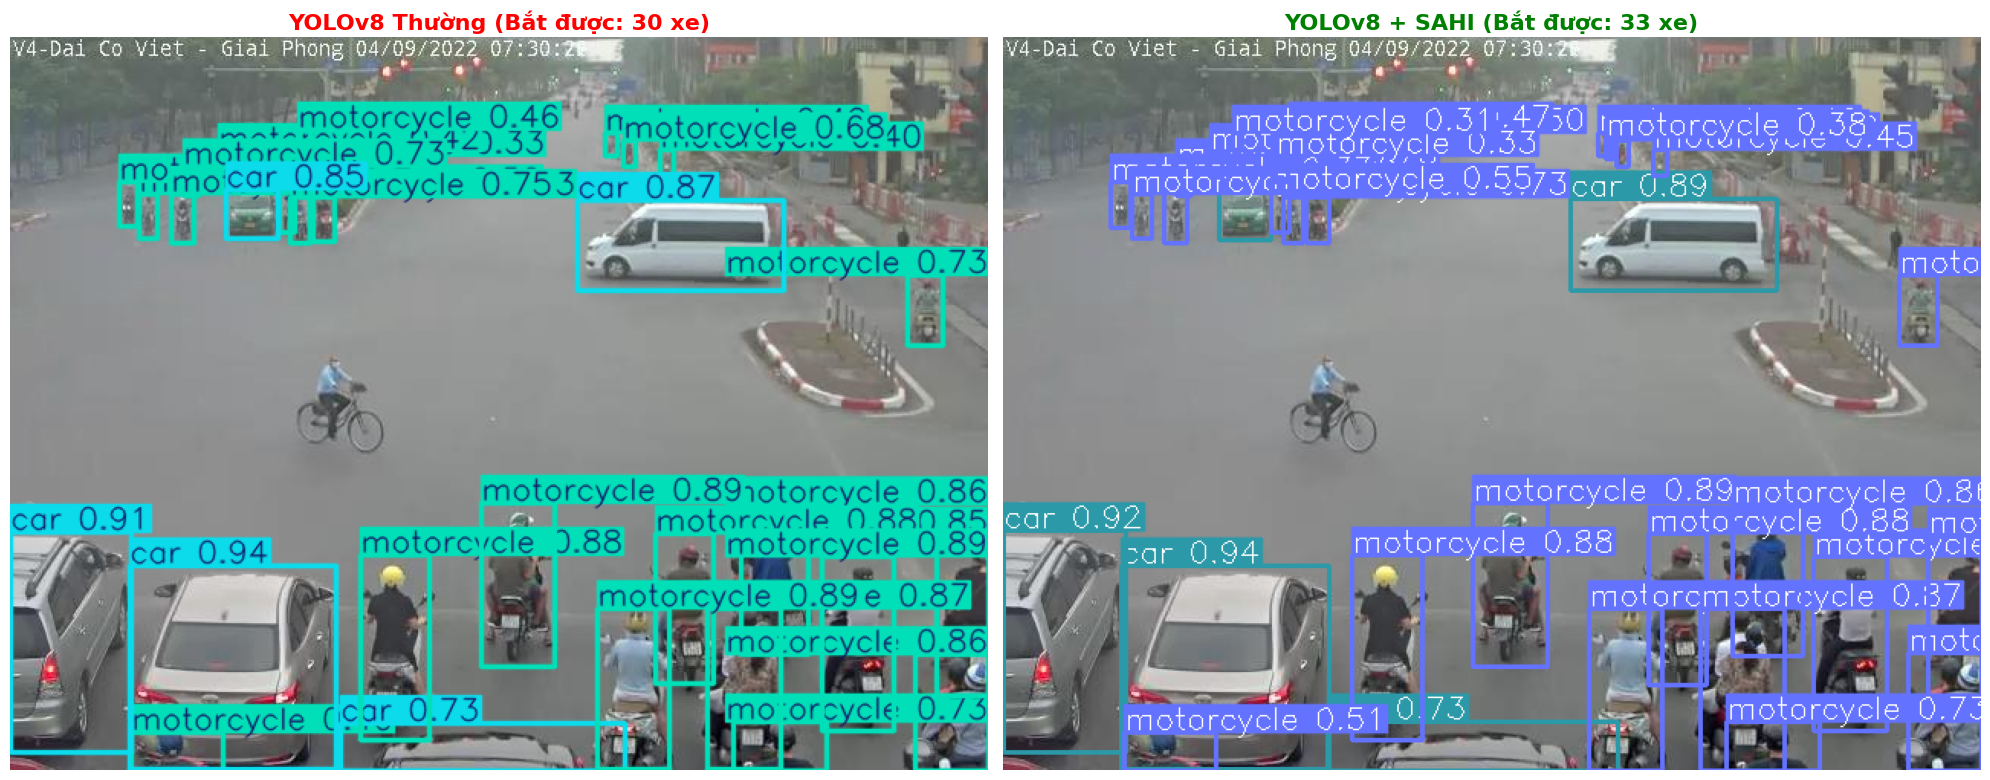

In [9]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN 
# ==========================================
WEIGHTS_PATH = "/kaggle/input/notebooks/thhtmnguyn21/trafic-project/Traffic_Project/model_yolov8_small_1024/weights/best.pt"
TEST_IMAGE_PATH = "/kaggle/input/datasets/thhtmnguyn21/traffic-project/traffic-vietnam-v1/test/images/Dai-Co-Viet-Giai-Phong_7h30-4-9-22_0003_jpg.rf.37ba318b3b40451087f35e12fd3d27b4.jpg" 

print("⏳ ĐANG CHẠY THỬ NGHIỆM A/B TESTING...")

# ==========================================
# PHẦN A: CHẠY YOLO BÌNH THƯỜNG (STANDARD INFERENCE)
# ==========================================
print("\n▶️ 1. Đang chạy YOLOv8 tiêu chuẩn...")
normal_model = YOLO(WEIGHTS_PATH)
normal_results = normal_model(TEST_IMAGE_PATH, imgsz=1024, conf=0.3, verbose=False)

# Lấy ảnh kết quả và số lượng xe đếm được
normal_img = normal_results[0].plot()
normal_count = len(normal_results[0].boxes)
print(f"   -> YOLO thường phát hiện được: {normal_count} đối tượng.")

# ==========================================
# PHẦN B: CHẠY YOLO KẾT HỢP SAHI (SLICED INFERENCE)
# ==========================================
print("▶️ 2. Đang chạy YOLOv8 + SAHI...")
sahi_model = AutoDetectionModel.from_pretrained(
    model_type='yolov8',
    model_path=WEIGHTS_PATH,
    confidence_threshold=0.3,
    device="cuda:0"
)

sahi_results = get_sliced_prediction(
    TEST_IMAGE_PATH,
    sahi_model,
    slice_height=512,
    slice_width=512,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
    verbose=0
)

# Để hiển thị đồng nhất, ta dùng hàm xuất ảnh của SAHI
OUTPUT_DIR = "/kaggle/working/sahi_comparison/"
sahi_results.export_visuals(export_dir=OUTPUT_DIR, file_name="sahi_result")
sahi_img = cv2.imread(f"{OUTPUT_DIR}/sahi_result.png")
sahi_img = cv2.cvtColor(sahi_img, cv2.COLOR_BGR2RGB) # Đổi hệ màu để in ra chuẩn

sahi_count = len(sahi_results.object_prediction_list)
print(f"   -> SAHI phát hiện được: {sahi_count} đối tượng.")

# ==========================================
# 3. TRỰC QUAN HÓA BẰNG CHỨNG (VẼ ĐỒ THỊ SO SÁNH)
# ==========================================
print(f"\n🏆 KẾT LUẬN: SAHI TĂNG HIỆU SUẤT NHẬN DIỆN THÊM {sahi_count - normal_count} ĐỐI TƯỢNG!")

# Ghép 2 ảnh cạnh nhau để so sánh
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(normal_img, cv2.COLOR_BGR2RGB))
plt.title(f"YOLOv8 Small (Bắt được: {normal_count} xe)", fontsize=16, fontweight='bold', color='red')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sahi_img)
plt.title(f"YOLOv8 Small + SAHI (Bắt được: {sahi_count} xe)", fontsize=16, fontweight='bold', color='green')
plt.axis('off')

plt.tight_layout()
plt.savefig("/kaggle/working/AB_Testing_Proof.png", dpi=300) # Lưu ảnh nét cao để in báo cáo
plt.show()